In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt


from GordonRitter.utils.bet_sizing_model_utils import BetSizingModel
from GordonRitter.utils.bet_sizing_env import TradingEnvironment


In [2]:

#data = pd.read_csv('Data/RL_Data_opt_timing_total.csv')
data = pd.read_csv('Data/RL_Data_opt_timing_total.csv')
data = data.sort_values('timestamp').reset_index(drop=True) # date sort
#state_columns = ['bid_price_1', 'bid_size_1', 'open', 'volume','daily_volume', 'volatility',
#               'EffectiveSpread', 'HLVolatility', 'CS_Spread','Kyle_Lambda', 'Volume_PIN','news_sentiment_score']
#state_columns = ['bid_price_1', 'bid_size_1', 'open', 'volume','daily_volume', 'volatility']
state_columns = ['Volume_PIN','daily_volume','bid_price_1','volatility','bid_size_1','news_sentiment_score','EffectiveSpread']
#optimal points per day
optm_pts_per_day = 20

# Unifying the type of numerical columns 
float_cols = data.select_dtypes(include=['float','int']).columns
data[float_cols] = data[float_cols].astype(np.float32)

#Handling missing values
rows_with_nan = data.isna().any(axis=1)
data.loc[rows_with_nan] = data.ffill().loc[rows_with_nan]
for col in data.columns:
    if data[col].isna().any():
        print(col)

print(f'Data shape:{data.shape}')

train_split = (int(data.shape[0]*0.8)//optm_pts_per_day)*optm_pts_per_day

data_train = data.iloc[:train_split]
data_test = data.iloc[train_split:]

# Min-Max normalization
data_min = data_train[float_cols].min()
data_max = data_train[float_cols].max()

data_max.to_csv('Models/bet_sizing_v1/max_values_to_resize_features.csv', header=True)
data_min.to_csv('Models/bet_sizing_v1/min_values_to_resize_features.csv', header=True)


for col in float_cols:
    data_train[col] = (data_train[col] - data_min[col])/(data_max[col]-data_min[col])
    data_test[col] = (data_test[col] - data_min[col])/(data_max[col]-data_min[col])



Data shape:(20720, 24)


/var/folders/73/r6fj47bs1vz8m5q3xtt377l80000gn/T/ipykernel_80116/1246913914.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_train[col] = (data_train[col] - data_min[col])/(data_max[col]-data_min[col])
/var/folders/73/r6fj47bs1vz8m5q3xtt377l80000gn/T/ipykernel_80116/1246913914.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_test[col] = (data_test[col] - data_min[col])/(data_max[col]-data_min[col])


/Users/weishiwang/Desktop/Jobs/blockhouse/GitHub/Blockhouse-Repo/Blockhouse-ML/blockhouse_ml/equities/sell/utils/data_handler.py:64: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.data['mid_price'] = (self.data['high'] + self.data['low']) / 2
/Users/weishiwang/Desktop/Jobs/blockhouse/GitHub/Blockhouse-Repo/Blockhouse-ML/blockhouse_ml/equities/sell/utils/data_handler.py:65: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.data["mean_vol"] = self.data['mid_price'].pct_change().rolling(window=window_size

True
Models/bet_sizing_v1/model.zip
True
Training from scratch...


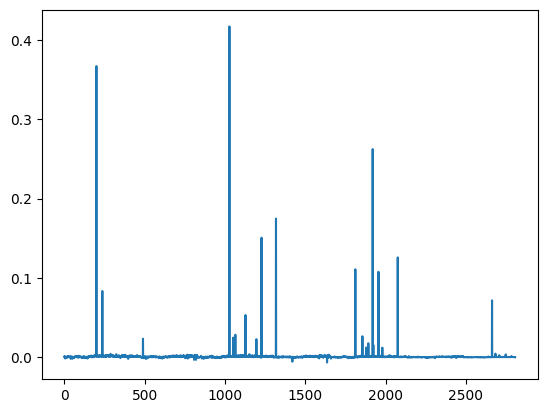

In [3]:

#Enviroment prep
env = TradingEnvironment(
    data=data_train,
    reset_count=optm_pts_per_day,
    initial_inventory=10000,
    state_columns=state_columns
)

model = BetSizingModel(name='model', env=env, overide=True, model_dir='Models/bet_sizing_v1')

#Training the model
model.train(10000)

plt.plot(env.penalty_trajectory)
plt.show()

train average penalty: 0.0012660811575956952 train average reward: 0.6296955117917188


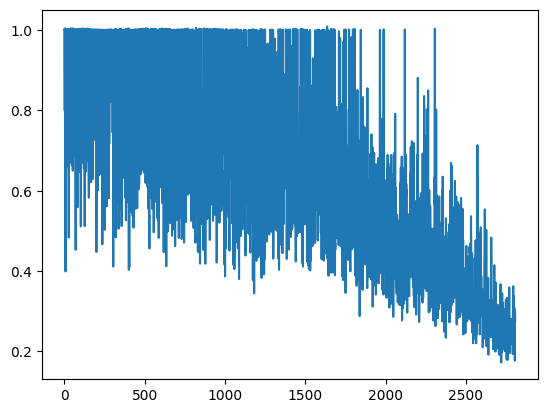

In [4]:
a=env.reward_trajectory
b=env.action_count_trajectory
c = [sum(a[sum(b[:i]):sum(b[:i+1])]) / b[i] for i in range(len(b))]
print("train average penalty:", np.mean(env.penalty_trajectory), 'train average reward:', np.mean(c))
plt.plot(c)
plt.show()

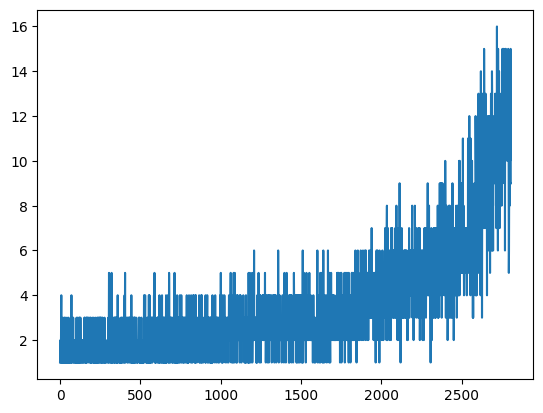

In [5]:
plt.plot(env.action_count_trajectory)
plt.show()

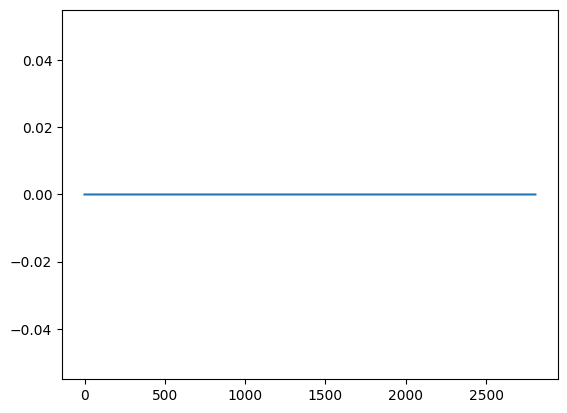

In [6]:
plt.plot(env.remaining_inventory_log)

In [7]:
env = TradingEnvironment(
    data=data_test,
    reset_count=optm_pts_per_day,
    initial_inventory=5000,
    state_columns=state_columns
)

model = BetSizingModel(name='model', env=env, model_dir='Models/bet_sizing_v1')

/Users/weishiwang/Desktop/Jobs/blockhouse/GitHub/Blockhouse-Repo/Blockhouse-ML/blockhouse_ml/equities/sell/utils/data_handler.py:64: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.data['mid_price'] = (self.data['high'] + self.data['low']) / 2
/Users/weishiwang/Desktop/Jobs/blockhouse/GitHub/Blockhouse-Repo/Blockhouse-ML/blockhouse_ml/equities/sell/utils/data_handler.py:65: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.data["mean_vol"] = self.data['mid_price'].pct_change().rolling(window=window_size

False
Models/bet_sizing_v1/model.zip
True
Model loaded from Models/bet_sizing_v1/model.zip


/Users/weishiwang/Desktop/Jobs/blockhouse/GitHub/Blockhouse-Repo/Blockhouse-ML/blockhouse_ml/equities/sell/utils/data_handler.py:104: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.data['transaction_cost'] = self.data.apply(almgren, axis=1)
/Users/weishiwang/Desktop/Jobs/blockhouse/GitHub/Blockhouse-Repo/Blockhouse-ML/GordonRitter/utils/bet_sizing_env.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.data.bfill(inplace=True)


In [8]:
model.test(env=env)

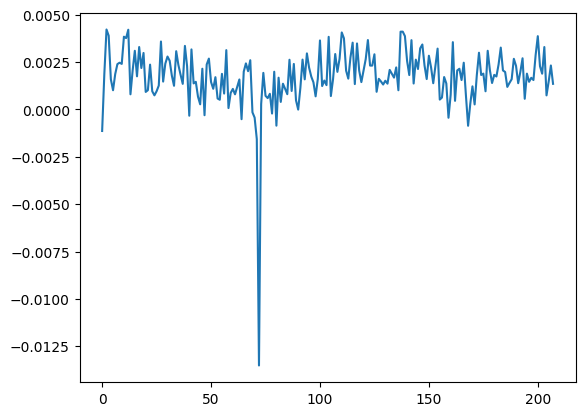

In [9]:
plt.plot(env.penalty_trajectory)
plt.show()

test average penalty: 0.0017448482567919857 test average reward: 0.8761232943609721


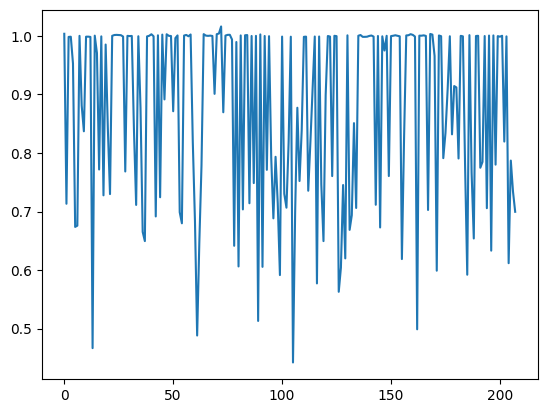

In [10]:
# c: average reward
a=env.reward_trajectory
b=env.action_count_trajectory
c = [sum(a[sum(b[:i]):sum(b[:i+1])]) / b[i] for i in range(len(b))]
print("test average penalty:", np.mean(env.penalty_trajectory), 'test average reward:', np.mean(c))
plt.plot(c)
plt.show()

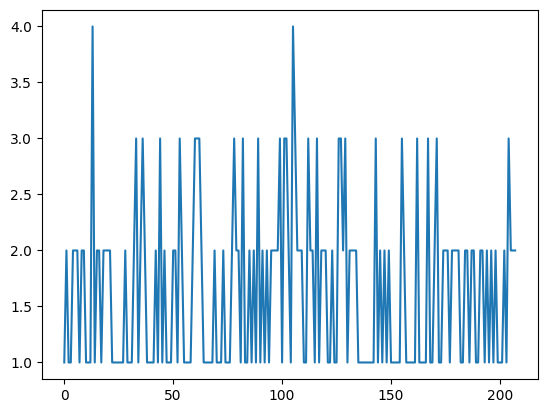

In [11]:
plt.plot(env.action_count_trajectory)
plt.show()

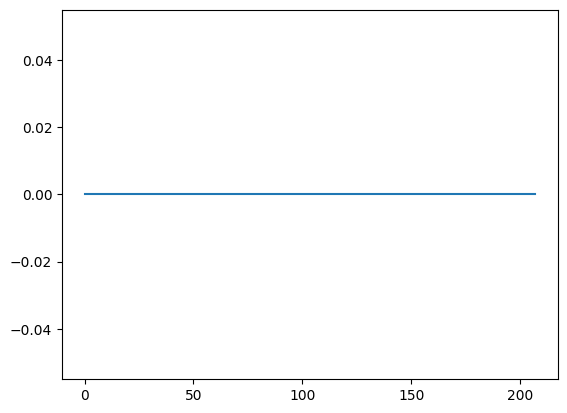

In [12]:
plt.plot(env.remaining_inventory_log)

In [13]:
for trade in env.tradelist:
    print(pd.DataFrame(trade, columns=['timestamp', 'volume']))

                   timestamp  volume
0  2024-07-10 14:48:00+00:00   10000
                   timestamp  volume
0  2024-07-10 16:14:00+00:00    2727
1  2024-07-10 18:07:00+00:00    7273
                   timestamp  volume
0  2024-07-10 18:48:00+00:00   10000
                   timestamp  volume
0  2024-07-10 19:23:00+00:00   10000
                   timestamp  volume
0  2024-07-11 16:02:00+00:00    8476
1  2024-07-11 16:03:00+00:00    1524
                   timestamp  volume
0  2024-07-11 17:55:00+00:00    2000
1  2024-07-11 17:56:00+00:00    8000
                   timestamp  volume
0  2024-07-11 18:48:00+00:00    2052
1  2024-07-11 18:49:00+00:00    7948
                   timestamp  volume
0  2024-07-11 19:10:00+00:00   10000
                   timestamp  volume
0  2024-07-12 15:41:00+00:00    6476
1  2024-07-12 15:42:00+00:00    3524
                   timestamp  volume
0  2024-07-12 17:02:00+00:00    5371
1  2024-07-12 17:03:00+00:00    4629
                   timestamp  volume
0

## feature importance

In [14]:
# Checkpoint cut
raise Exception
feature_importance = pd.DataFrame({'Feature':state_columns,'Before_perm_penalty':np.repeat(np.mean(env.penalty_trajectory),len(state_columns)), 
                                   'After_perm_penalty':np.zeros(len(state_columns)),
                                   'Before_perm_reward':np.repeat(np.mean(c),len(state_columns)),
                                   'After_perm_reward': np.zeros(len(state_columns))})

Exception: 

In [ ]:
data_to_perm = data_test.copy()
for i in range(len(state_columns)):
    col = state_columns[i]
    data_to_perm[col] = np.random.permutation(data_to_perm[col])
    env = TradingEnvironment(
        data=data_to_perm,
        reset_count=optm_pts_per_day,
        initial_inventory=10000,
        state_columns=state_columns
    )
    model = BetSizingModel(name='model', env=env, model_dir='Models/bet_sizing_v1')
    model.test(env=env)
    feature_importance.iloc[i,2] = np.mean(env.penalty_trajectory)
    a=env.reward_trajectory
    b=env.action_count_trajectory
    c = [sum(a[sum(b[:i]):sum(b[:i+1])]) / b[i] for i in range(len(b))]
    feature_importance.iloc[i,4] = np.mean(c)

In [ ]:
feature_importance['diff_penalty'] = feature_importance['Before_perm_penalty'] - feature_importance['After_perm_penalty']
feature_importance['diff_reward'] = feature_importance['Before_perm_reward'] - feature_importance['After_perm_reward']
df1=feature_importance.sort_values(by='diff_penalty',ascending=True)
df2=feature_importance.sort_values(by='diff_reward',ascending=False)
print(df1[['Feature','diff_penalty']])
print('-----------------------------------------')
print(df2[['Feature','diff_reward']])

## we select features: 
['Volume_PIN','daily_volume','bid_price_1','volatility','bid_size_1','news_sentiment_score','EffectiveSpread']

In [ ]:
# cut here
raise Exception

In [ ]:
data = pd.read_csv('Data/RL_Data_opt_timing_total.csv')
data = data.sort_values('timestamp').reset_index(drop=True) # date sort
state_columns = ['bid_price_1', 'bid_size_1', 'open', 'volume','daily_volume', 'volatility']
#optimal points per day
optm_pts_per_day = 20

# Unifying the type of numerical columns 
float_cols = data.select_dtypes(include=['float','int']).columns
data[float_cols] = data[float_cols].astype(np.float32)

#Handling missing values
rows_with_nan = data.isna().any(axis=1)
data.loc[rows_with_nan] = data.ffill().loc[rows_with_nan]
for col in data.columns:
    if data[col].isna().any():
        print(col)

print(f'Data shape:{data.shape}')

train_split = (int(data.shape[0]*0.8)//optm_pts_per_day)*optm_pts_per_day

data_train = data.iloc[:train_split]
data_test = data.iloc[train_split:]

# Min-Max normalization
data_min = data_train[float_cols].min()
data_max = data_train[float_cols].max()

data_max.to_csv('Models/bet_sizing_v1/max_values_to_resize_features.csv', header=True)
data_min.to_csv('Models/bet_sizing_v1/min_values_to_resize_features.csv', header=True)


for col in float_cols:
    data_train[col] = (data_train[col] - data_min[col])/(data_max[col]-data_min[col])
    data_test[col] = (data_test[col] - data_min[col])/(data_max[col]-data_min[col])

env = TradingEnvironment(
    data=data_train,
    reset_count=optm_pts_per_day,
    initial_inventory=10000,
    state_columns=state_columns
)

model = BetSizingModel(name='model', env=env, overide=True, model_dir='Models/bet_sizing_v1')

#Training the model
model.train(10000)
env = TradingEnvironment(
    data=data_test,
    reset_count=optm_pts_per_day,
    initial_inventory=10000,
    state_columns=state_columns
)

model = BetSizingModel(name='model', env=env, model_dir='Models/bet_sizing_v1')
model.test(env=env)
a=env.reward_trajectory
b=env.action_count_trajectory
c=[sum(a[sum(b[:i]):sum(b[:i+1])]) / b[i] for i in range(len(b))]
feature_importance = pd.DataFrame({'Feature':state_columns,'Before_perm_penalty':np.repeat(np.mean(env.penalty_trajectory),len(state_columns)), 
                                   'After_perm_penalty':np.zeros(len(state_columns)),
                                   'Before_perm_reward':np.repeat(np.mean(c),len(state_columns)),
                                   'After_perm_reward': np.zeros(len(state_columns))})
data_to_perm = data_test.copy()
for i in range(len(state_columns)):
    col = state_columns[i]
    data_to_perm[col] = np.random.permutation(data_to_perm[col])
    env = TradingEnvironment(
        data=data_to_perm,
        reset_count=optm_pts_per_day,
        initial_inventory=10000,
        state_columns=state_columns
    )
    model = BetSizingModel(name='model', env=env, model_dir='Models/bet_sizing_v1')
    model.test(env=env)
    feature_importance.iloc[i,2] = np.mean(env.penalty_trajectory)
    a=env.reward_trajectory
    b=env.action_count_trajectory
    c = [sum(a[sum(b[:i]):sum(b[:i+1])]) / b[i] for i in range(len(b))]
    feature_importance.iloc[i,4] = np.mean(c)
feature_importance['diff_penalty'] = feature_importance['Before_perm_penalty'] - feature_importance['After_perm_penalty']
feature_importance['diff_reward'] = feature_importance['Before_perm_reward'] - feature_importance['After_perm_reward']
df1=feature_importance.sort_values(by='diff_penalty',ascending=True)
df2=feature_importance.sort_values(by='diff_reward',ascending=False)
print(df1[['Feature','diff_penalty']])
print('-----------------------------------------')
print(df2[['Feature','diff_reward']])

## the feature importance contradicts each-other in Simple State Space.